In [52]:
import torch
from neural_lam.weather_dataset import WeatherDataset

# if you change the seed, make sure that the randomly-applied transforms
# properly show that the image can be both transformed and *not* transformed!
torch.manual_seed(0)
standardize = True

dataset = WeatherDataset(
            "meps_example",
            pred_length=1,
            split="train",
            subsample_step=3,
            subset=bool(0),
            control_only=0,
            standardize=standardize,
            border_condition=True
        )

sample_idx = 0 # torch.randint(len(dataset), size=(1,)).item()
init_states, target_states, forcing, boundary_forcing = dataset[sample_idx]

print(f"init_states shape: {init_states.shape}")
print(f"target_states shape: {target_states.shape}")
print(f"forcing shape: {forcing.shape}")
print(f"boundary_forcing shape: {boundary_forcing.shape}")

Loading sample from /proj/berzelius-2022-164/weather/neural_lam_datasets/meps_example/samples/train/nwp_2022040100_mbr000.npy
Sample name: 2022040100_mbr000
index: 0
init_states shape: torch.Size([2, 54064, 17])
target_states shape: torch.Size([1, 54064, 17])
forcing shape: torch.Size([1, 54064, 16])
boundary_forcing shape: torch.Size([1, 9720, 67])


In [53]:
from neural_lam import utils, config

static_data_dict = utils.load_static_data("meps_example")
data_config = config.Config.from_file("neural_lam/data_config.yaml")

for key, value in static_data_dict.items():
    print(f"{key}: {value}")

boundary_mask: tensor([True, True, True,  ..., True, True, True])
interior_mask: tensor([False, False, False,  ..., False, False, False])
grid_static_features: tensor([[-0.7179, -0.9216,  0.0273,  0.0000],
        [-0.7104, -0.9216,  0.0139,  0.0000],
        [-0.7029, -0.9216,  0.0136,  0.0000],
        ...,
        [ 0.8897,  0.9252,  0.0137,  0.0000],
        [ 0.8971,  0.9252,  0.0139,  0.0000],
        [ 0.9046,  0.9252,  0.0138,  0.0000]])
boundary_static_features: tensor([[-0.7927, -0.9964,  0.0135,  1.0000],
        [-0.7852, -0.9964,  0.0134,  1.0000],
        [-0.7777, -0.9964,  0.0139,  1.0000],
        ...,
        [ 0.9644,  1.0000,  0.1689,  1.0000],
        [ 0.9719,  1.0000,  0.1180,  1.0000],
        [ 0.9794,  1.0000,  0.1094,  1.0000]])
step_diff_mean: tensor([-0.0181, -0.0576,  0.0104,  0.0003,  0.0078,  0.0059,  0.0120,  0.0120,
        -0.0030,  0.0141,  0.0020,  0.0173,  0.0162,  0.0046,  0.0112, -0.0569,
        -0.0271])
step_diff_std: tensor([0.0459, 0.1482, 0

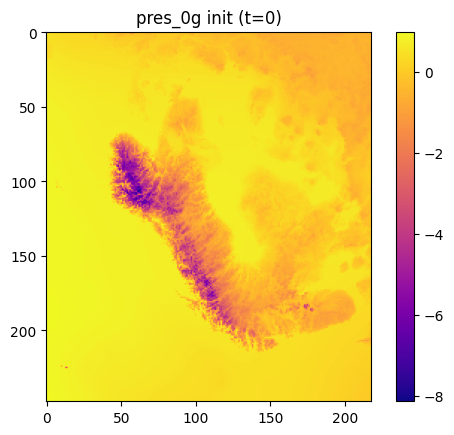

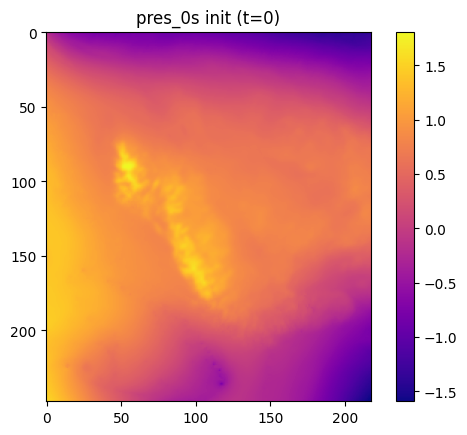

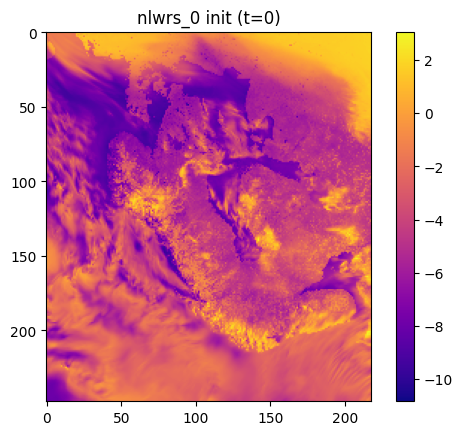

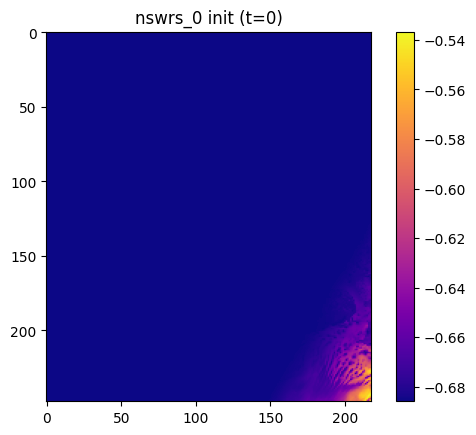

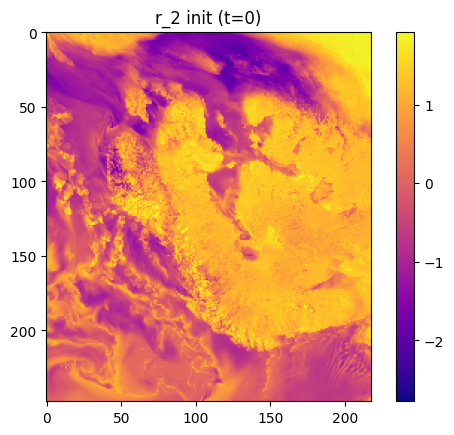

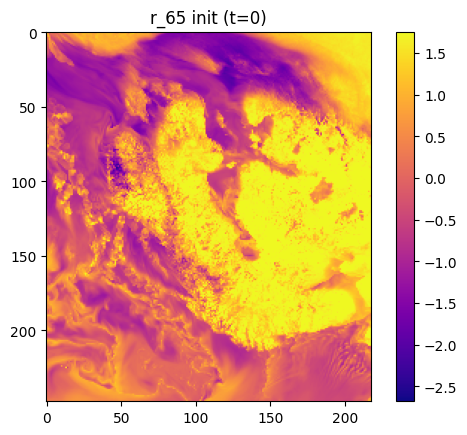

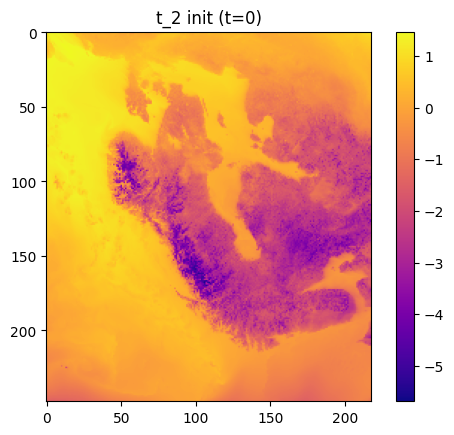

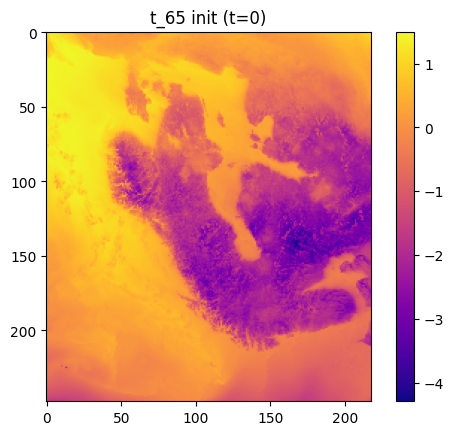

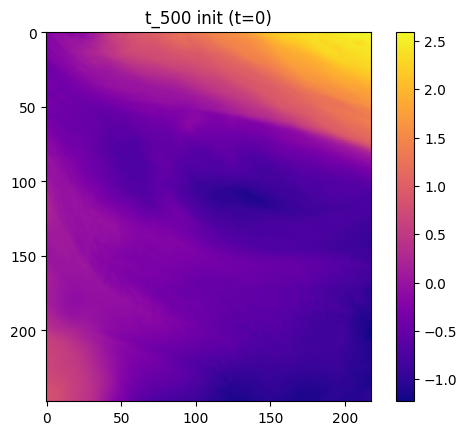

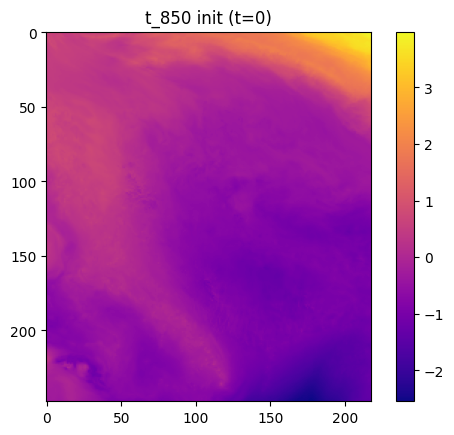

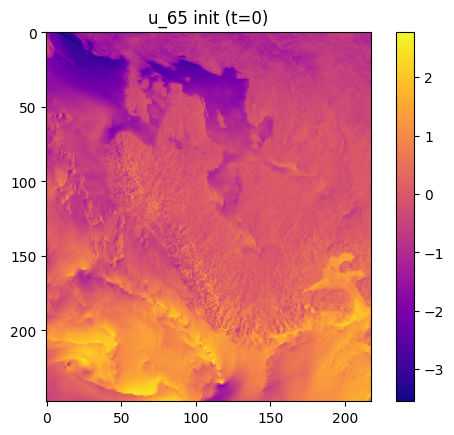

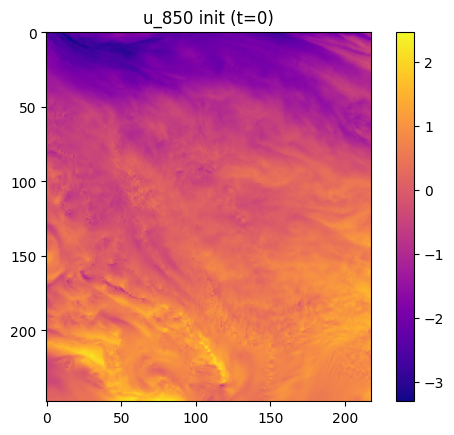

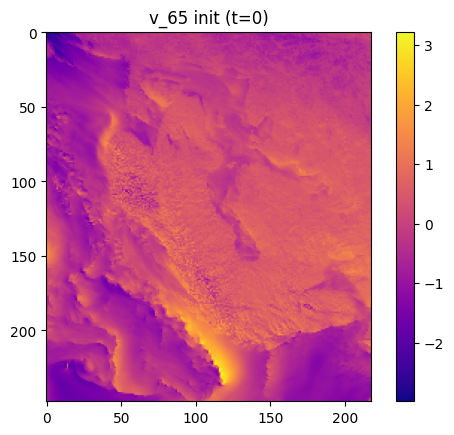

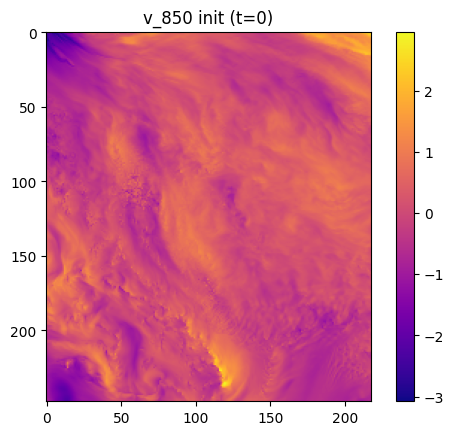

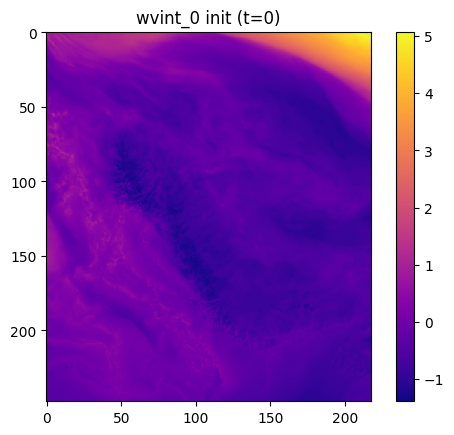

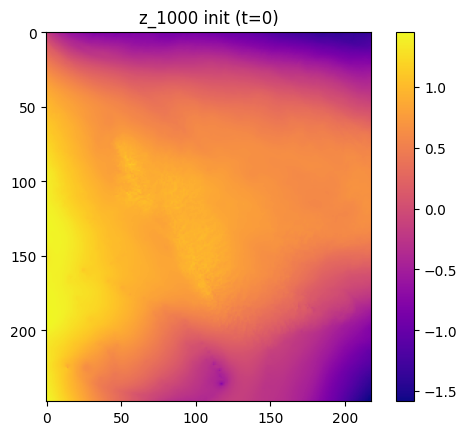

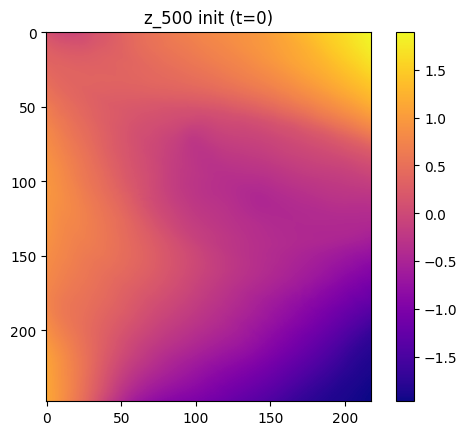

In [54]:
import matplotlib.pyplot as plt
import os
GRID_SHAPE = (248, 218)  # (y, x) without border
FULL_GRID_SHAPE = (268, 238)

time_idx = 0  # choose which timestep to plot
output_dir = "./state_debug_OG"
if standardize:
    output_dir += "_standardized"
os.makedirs(output_dir, exist_ok=True)
for var_idx, var_name in enumerate(data_config.dataset.var_names):
    # init_states assumed shape (T, N, V) -> reshape to (T, Y, X, V)
    arranged = init_states.reshape(init_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)
    img = arranged[time_idx, ..., var_idx]
    torch.save(img, os.path.join(output_dir, f"MEPS_OG_{var_name}_init_t{time_idx}.pt"))
    img = img.cpu().numpy() if hasattr(img, "cpu") else img.numpy()

    plt.figure()
    plt.imshow(img, cmap="plasma")
    plt.title(f"{var_name} init (t={time_idx})")
    plt.colorbar()
    plt.savefig(os.path.join(output_dir, f"MEPS_OG_{var_name}_init_t{time_idx}.png"))